In [7]:
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import OptimalBattery.plot as plot
import OptimalBattery.global_config as gcf
from scipy.stats import ttest_rel


save_dir = gcf.save_dir


In [2]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_connectivity_org.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [3]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc','log_det_mc']
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

In [4]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

In [5]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

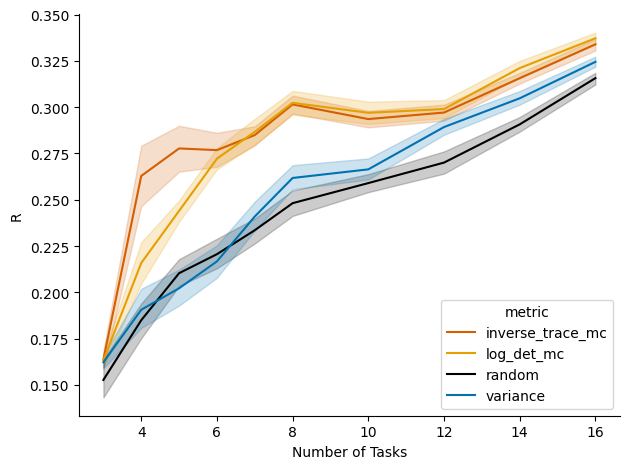

In [6]:
sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("R")
# remove legend 
plt.tight_layout()
sns.despine()
plt.savefig(f"{save_dir}/battery_criteria/real_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [8]:
D

,n_task,metric,avg_correlation_per_subject,sub,adjusted
0,3,inverse_trace_mc,0.224463,1,0.188351
1,3,inverse_trace_mc,0.051424,2,0.132222
2,3,inverse_trace_mc,0.133324,3,0.173692
3,3,inverse_trace_mc,0.235516,4,0.164631
4,3,inverse_trace_mc,0.169631,5,0.161146
...,...,...,...,...,...
1171,16,variance,0.347433,20,0.314433
1172,16,variance,0.251965,21,0.311756
1173,16,variance,0.288935,22,0.328873
1174,16,variance,0.293244,23,0.319280


In [14]:
results = []

for n in D['n_task'].unique():
    sub_df = D[D['n_task'] == n]

    a = sub_df[sub_df['metric'] == 'inverse_trace_mc'].sort_values('sub')['avg_correlation_per_subject']
    b = sub_df[sub_df['metric'] == 'variance'].sort_values('sub')['avg_correlation_per_subject']

    # Only run if both have the same subjects
    if len(a) == len(b):
        t, p = ttest_rel(a, b)
        results.append([n, t, p])

res_df = pd.DataFrame(results, columns=['n_task', 't', 'p'])
print(res_df)

   n_task         t             p
0       3  1.024014  3.164791e-01
1       4  5.940390  4.680673e-06
2       5  7.042351  3.554801e-07
3       6  6.720724  7.429310e-07
4       7  7.124767  2.949232e-07
5       8  6.830689  5.765707e-07
6      10  5.204608  2.812084e-05
7      12  1.828948  8.040433e-02
8      14  3.426980  2.302807e-03
9      16  3.351950  2.761625e-03
